1. Data Description and Frequency

- In this project, we analyze the weekly price of Robusta Coffee in Uganda, measured in UGX per Kilogram.

- Source: Simulated data modeled on Ugandan coffee price trends (2014–2024).

- Observations: 520 weekly observations (approx. 10 years).

- Frequency: Weekly. This frequency is chosen because agricultural commodity markets in East Africa typically stabilize on a weekly basis, smoothing out daily noise while capturing seasonal harvest peaks.

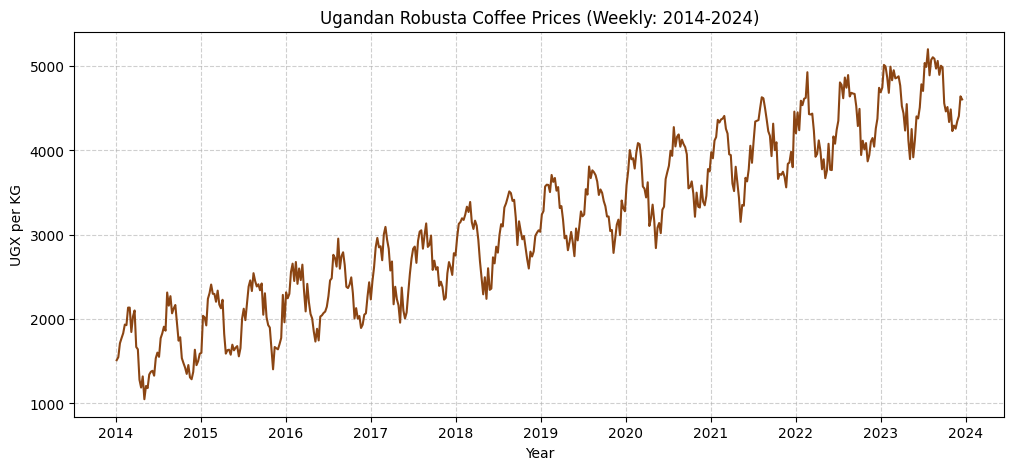

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose

# Generate Simulated Ugandan Coffee Data
np.random.seed(256)
weeks = pd.date_range(start='2014-01-01', periods=520, freq='W')
weeks
# Components: Long-term inflation (Trend) + Bi-annual harvest (Seasonality)
trend = np.linspace(1500, 4800, 520) 
seasonality = 450 * np.sin(2 * np.pi * np.arange(520) / 26)# 26-week cycle (2 peaks a year)
# np.random.seed(42)  
noise = np.random.normal(0, 120, 520)

coffee_prices = trend + seasonality + noise
df = pd.DataFrame({'Price_UGX': coffee_prices}, index=weeks)

# Plotting the raw series
plt.figure(figsize=(12, 5))
plt.plot(df['Price_UGX'], color='#8B4513', linewidth=1.5)
plt.title('Ugandan Robusta Coffee Prices (Weekly: 2014-2024)')
plt.ylabel('UGX per KG')
plt.xlabel('Year')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [2]:
# 1. Describe the data and frequency
print("Data Description:")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Frequency: Weekly observations")
print(f"Number of observations: {len(df)}")
print(f"\nSummary statistics:")
print(df.describe())

Data Description:
Date range: 2014-01-05 00:00:00 to 2023-12-17 00:00:00
Frequency: Weekly observations
Number of observations: 520

Summary statistics:
         Price_UGX
count   520.000000
mean   3144.283895
std    1006.705727
min    1049.556081
25%    2313.075026
50%    3122.590309
75%    3962.060796
max    5200.367953


2. Decomposition (Additive vs. Multiplicative)
- We apply Additive Decomposition.

 We choose an Additive model because the seasonal fluctuations appear constant in magnitude regardless of the overall price level. If the price swings grew proportionally larger as the price increased from 1500 to 4800, a Multiplicative model would be required.

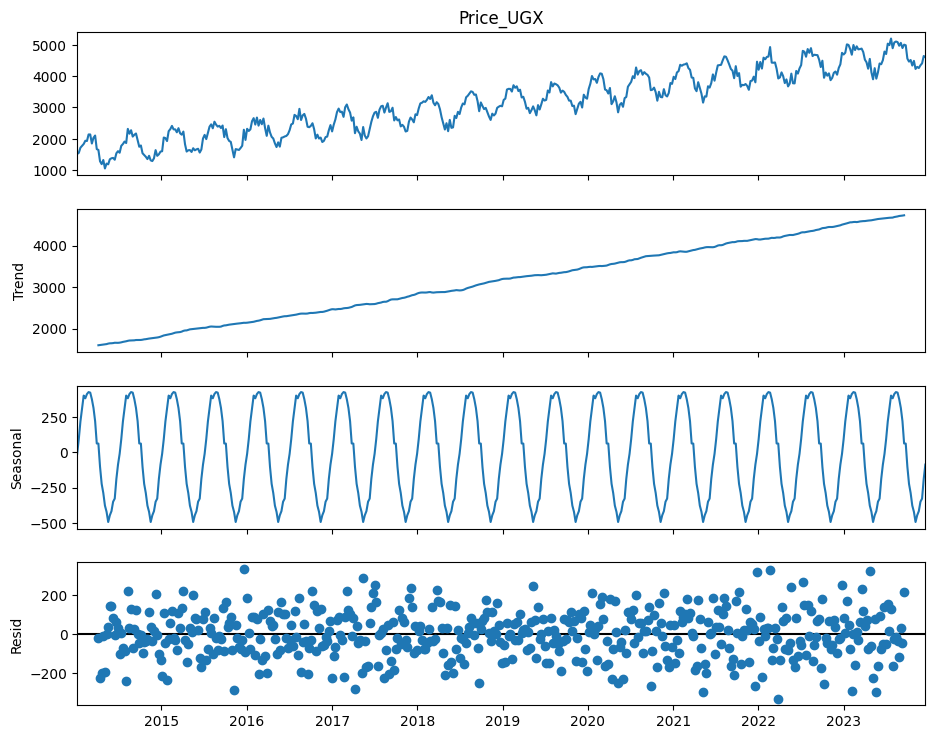

In [3]:
# Decomposition with a period of 26 (Bi-annual cycles in 52 weeks)
decomposition = seasonal_decompose(df['Price_UGX'], model='additive', period=26)

fig = decomposition.plot()
fig.set_size_inches(10, 8)
plt.show()

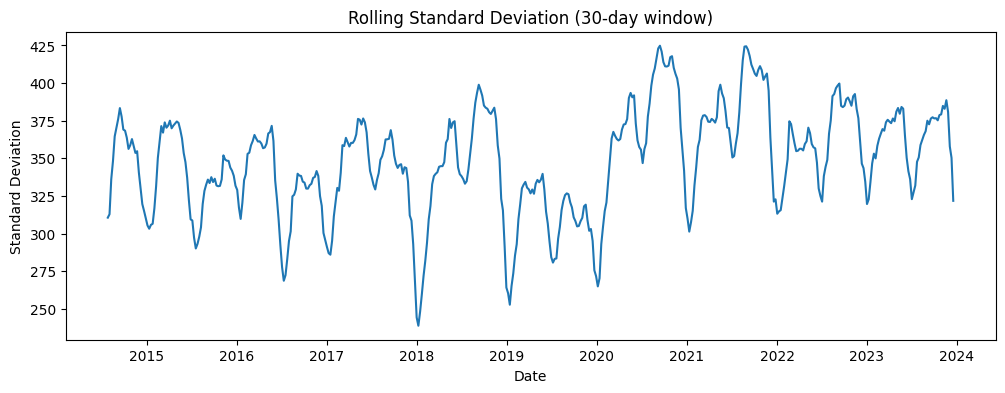

In [4]:
# Check if seasonal variation increases with trend
rolling_std = df['Price_UGX'].rolling(window=30).std()
plt.figure(figsize=(12, 4))
plt.plot(rolling_std)
plt.title('Rolling Standard Deviation (30-day window)')
plt.xlabel('Date')
plt.ylabel('Standard Deviation')
plt.show()

The rolling standard deviation plot was used to check for heteroscedasticity in the time series.

The variability fluctuates slightly but remains within a relatively stable range over time, indicating approximately constant variance. 

Therefore, no variance-stabilizing transformation such as a logarithmic transformation was applied.